EDA Plots (Ireland 2010–2024)

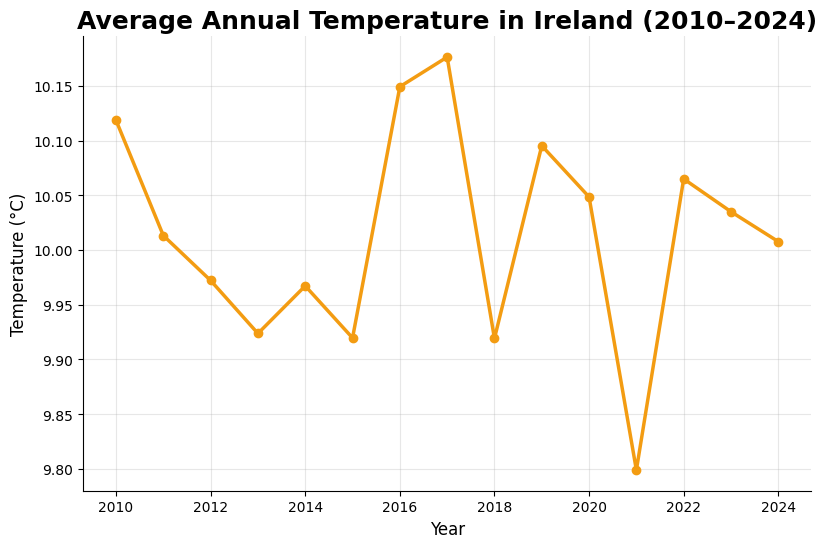

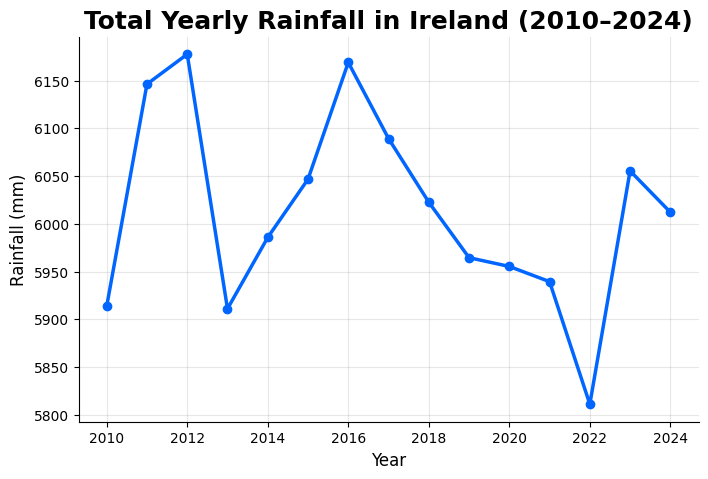

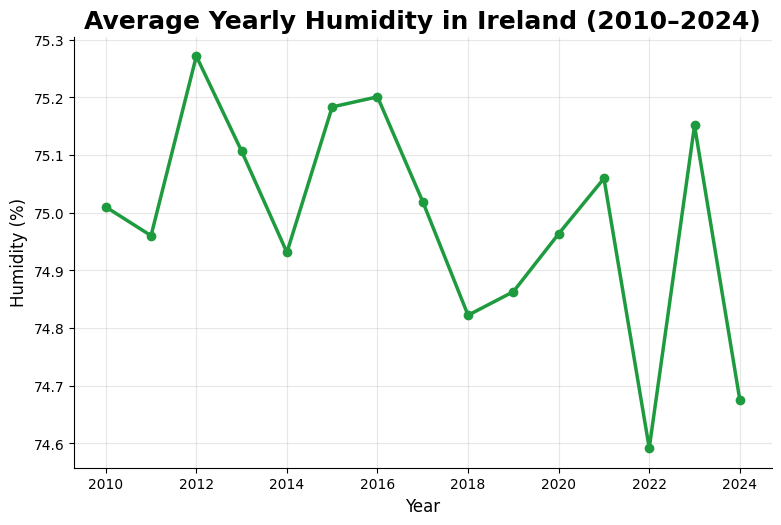

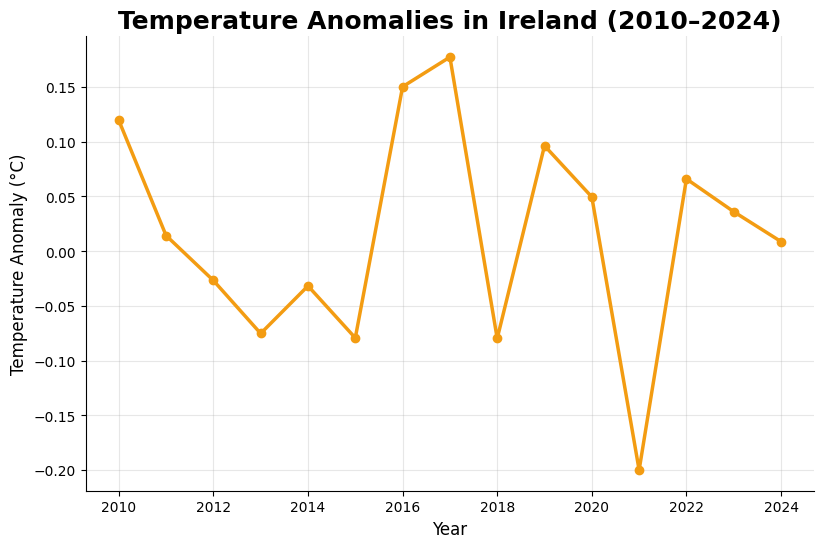

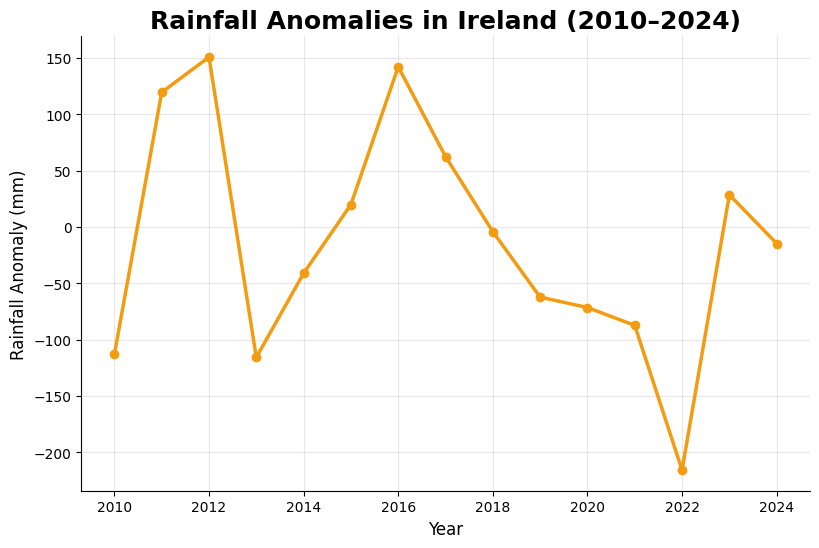

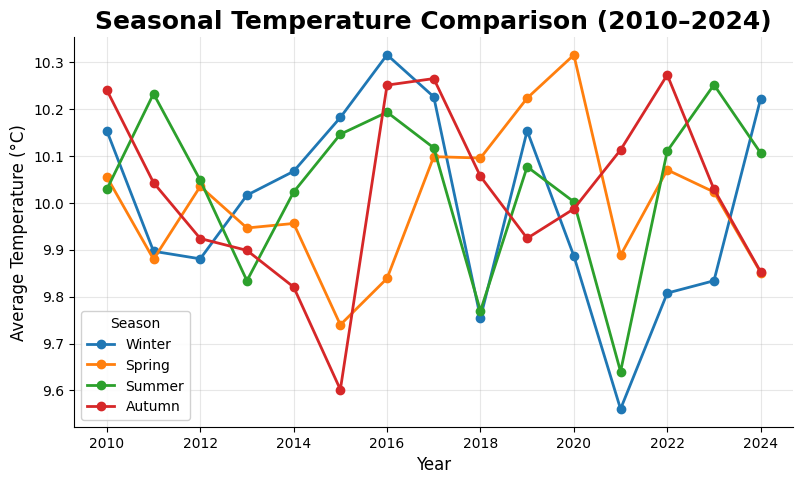

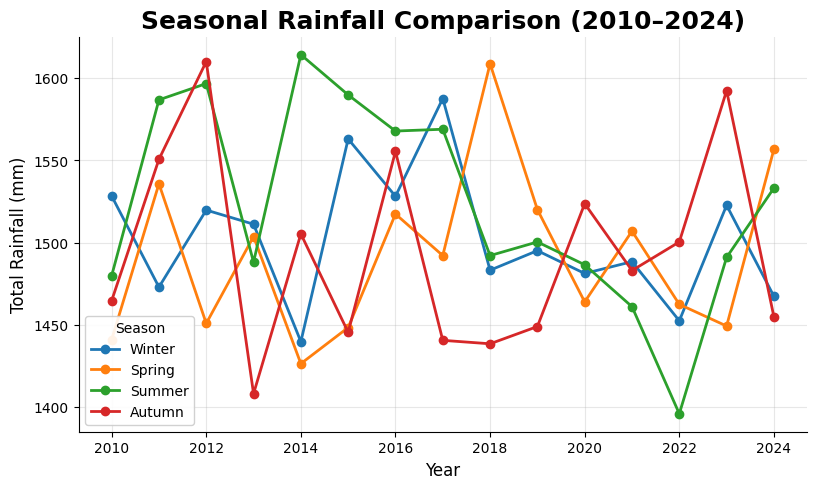

In [2]:


import os, math, numpy as np, pandas as pd, matplotlib.pyplot as plt

# ---------Load ----------
DATA_PATH = "/content/Integrated_Irish_Weather_2010_2024.xlsx"
df = pd.read_excel(DATA_PATH)


rename_map = {
    "date_time":"date", "Date":"date", "DATE":"date",
    "tmean":"tmean_c", "temp_mean":"tmean_c", "Temperature":"tmean_c",
    "temperature":"tmean_c", "Temp_C":"tmean_c",
    "rain":"rain_mm", "Rain":"rain_mm", "rainfall":"rain_mm",
    "Rainfall":"rain_mm", "precip_mm":"rain_mm", "precipitation_mm":"rain_mm",
    "humidity":"rh_pct", "Humidity":"rh_pct", "RH":"rh_pct"
}
df = df.rename(columns={k:v for k,v in rename_map.items() if k in df.columns})


date_col = next(c for c in ["date","Date","DATE"] if c in df.columns)
temp_col = next(c for c in ["tmean_c","Temperature (°C)","avg_temp","temperature","tmean"] if c in df.columns)
rain_col = next(c for c in ["rain_mm","Rain (mm)","rain","rainfall","precip_mm", "Rainfall (mm)"] if c in df.columns)
hum_col  = next(c for c in ["rh_pct","humidity","Humidity (%)","Humidity"] if c in df.columns)


df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
df = df.dropna(subset=[date_col]).sort_values(date_col).copy()
df["year"] = df[date_col].dt.year
df["month"] = df[date_col].dt.month


def month_to_season(m):
    if m in (12,1,2):  return "Winter"
    if m in (3,4,5):   return "Spring"
    if m in (6,7,8):   return "Summer"
    return "Autumn"
df["season"] = df["month"].map(month_to_season)

#  Yearly aggregates ----------
yr_temp = df.groupby("year")[temp_col].mean().loc[2010:2024]
yr_rain = df.groupby("year")[rain_col].sum().loc[2010:2024]
yr_hum  = df.groupby("year")[hum_col ].mean().loc[2010:2024]

# Baselines for anomalies
temp_baseline = yr_temp.loc[2010:2014].mean()
rain_baseline = yr_rain.loc[2010:2014].mean()

temp_anom = yr_temp - temp_baseline
rain_anom = yr_rain - rain_baseline

years = yr_temp.index.values


def style_axes(ax, title, xlabel, ylabel):
    ax.set_title(title, fontsize=18, weight="bold")
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.grid(True, alpha=0.3)
    for spine in ["top","right"]:
        ax.spines[spine].set_visible(False)

# - Average Annual Temperature ----------
fig, ax = plt.subplots(figsize=(9.4, 5.9))
ax.plot(years, yr_temp.values, marker="o", linewidth=2.5, color="#F39C12")
style_axes(ax, "Average Annual Temperature in Ireland (2010–2024)", "Year", "Temperature (°C)")
plt.show()

# Total Yearly Rainfall ----------
fig, ax = plt.subplots(figsize=(8.0, 5.0))
ax.plot(years, yr_rain.values, marker="o", linewidth=2.5, color="#0066FF")
style_axes(ax, "Total Yearly Rainfall in Ireland (2010–2024)", "Year", "Rainfall (mm)")
plt.show()

# - Average Yearly Humidity ----------
fig, ax = plt.subplots(figsize=(9.0, 5.6))
ax.plot(years, yr_hum.values, marker="o", linewidth=2.5, color="#1E9B3E")
style_axes(ax, "Average Yearly Humidity in Ireland (2010–2024)", "Year", "Humidity (%)")
plt.show()

#  Temperature Anomalies ----------
fig, ax = plt.subplots(figsize=(9.4, 5.9))
ax.plot(years, temp_anom.values, marker="o", linewidth=2.5, color="#F39C12")
style_axes(ax, "Temperature Anomalies in Ireland (2010–2024)", "Year", "Temperature Anomaly (°C)")
plt.show()

# - Rainfall Anomalies ----------
fig, ax = plt.subplots(figsize=(9.4, 5.9))
ax.plot(years, rain_anom.values, marker="o", linewidth=2.5, color="#F39C12")
style_axes(ax, "Rainfall Anomalies in Ireland (2010–2024)", "Year", "Rainfall Anomaly (mm)")
plt.show()

# - Seasonal aggregates ----------
# Temperature: seasonal mean per year
season_temp = df.groupby(["year","season"])[temp_col].mean().unstack("season").loc[2010:2024]
# Rainfall: seasonal totals per year
season_rain = df.groupby(["year","season"])[rain_col].sum().unstack("season").loc[2010:2024]

for frame in (season_temp, season_rain):
    for s in ["Winter","Spring","Summer","Autumn"]:
        if s not in frame.columns:
            frame[s] = np.nan
    frame[:] = frame[["Winter","Spring","Summer","Autumn"]]

# --Seasonal Temperature Comparison ----------
fig, ax = plt.subplots(figsize=(9.28, 5.06))
for season, color in zip(["Winter","Spring","Summer","Autumn"], ["#1f77b4","#ff7f0e","#2ca02c","#d62728"]):
    ax.plot(season_temp.index, season_temp[season], marker="o", linewidth=2, label=season, color=color)
style_axes(ax, "Seasonal Temperature Comparison (2010–2024)", "Year", "Average Temperature (°C)")
leg = ax.legend(title="Season", frameon=True)
leg.get_frame().set_alpha(0.9)
plt.show()

# ...Seasonal Rainfall Comparison ----------
fig, ax = plt.subplots(figsize=(9.4, 5.13))
for season, color in zip(["Winter","Spring","Summer","Autumn"], ["#1f77b4","#ff7f0e","#2ca02c","#d62728"]):
    ax.plot(season_rain.index, season_rain[season], marker="o", linewidth=2, label=season, color=color)
style_axes(ax, "Seasonal Rainfall Comparison (2010–2024)", "Year", "Total Rainfall (mm)")
leg = ax.legend(title="Season", frameon=True)
leg.get_frame().set_alpha(0.9)
plt.show()